In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression , Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import numpy as np
import seaborn as sns
from sklearn.model_selection import GridSearchCV,validation_curve
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.manifold import TSNE

from sklearn.linear_model import RidgeCV


import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('fifa.csv', index_col = 'name')

In [4]:
#data.head()

In [5]:
forwards =  data[data['position'] == 'Attack']

In [6]:
forwards = forwards.drop(['position', 'data_year','position'], axis = 1)

In [7]:
# Define the features (X) and target (y)
X = forwards.drop('overall', axis=1)
y = forwards['overall']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
def categorize_overall(overall):
    if 90 <= overall <= 99:
        return '90+'
    elif 80 <= overall <= 89:
        return '80+'
    elif 70 <= overall <= 79:
        return '70+'
    elif 60 <= overall <= 69:
        return '60+'
    elif 50 <= overall <= 59:
        return '50+'
    else:
        return '50-'



In [9]:
# Apply the function to create a new column
forwards['type'] = forwards['overall'].apply(categorize_overall)
forwards = forwards.reset_index()


In [10]:
forwards_pca = forwards.drop(['name'], axis = 1)

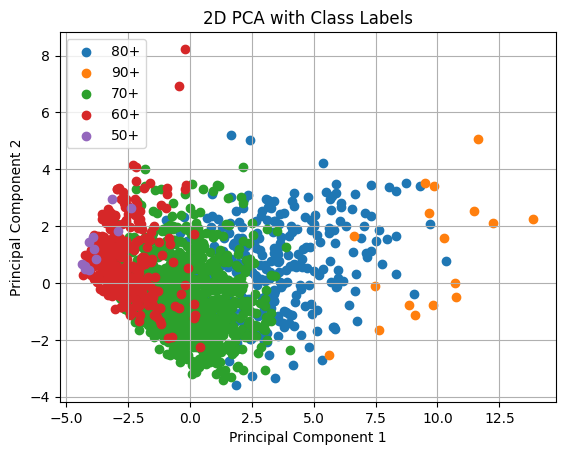

In [11]:
# Separate features and class labels
features = forwards_pca.drop(['type'], axis=1)
labels = forwards_pca['type']

# Standardize the features (important for PCA)
features = StandardScaler().fit_transform(features)

# Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
principal_components = pca.fit_transform(features)
principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Concatenate with class labels
final_df = pd.concat([principal_df, labels], axis=1)

# Plotting
fig, ax = plt.subplots()
for label in final_df['type'].unique():
    indices_to_keep = final_df['type'] == label
    ax.scatter(final_df.loc[indices_to_keep, 'PC1'], 
               final_df.loc[indices_to_keep, 'PC2'], 
               label=label)
ax.legend()
ax.grid()
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA with Class Labels')
plt.show()

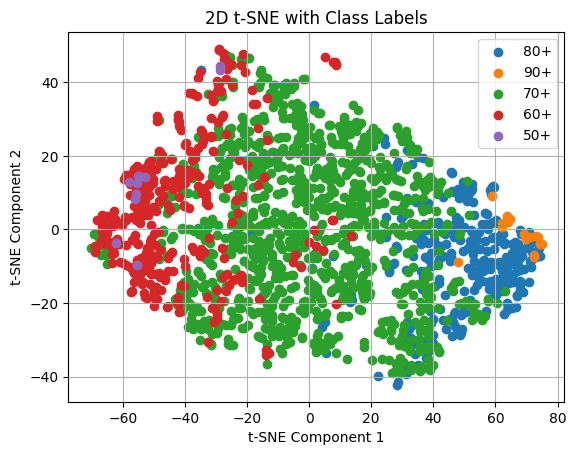

In [12]:
# Apply t-SNE
tsne = TSNE(n_components=2, verbose=0, perplexity=30, n_iter=3000)
tsne_results = tsne.fit_transform(features)

# Create a DataFrame for the t-SNE results
tsne_df = pd.DataFrame(data=tsne_results, columns=['TSNE1', 'TSNE2'])

# Concatenate with class labels
final_df = pd.concat([tsne_df, labels], axis=1)

# Plotting
fig, ax = plt.subplots()
for label in final_df['type'].unique():
    indices_to_keep = final_df['type'] == label
    ax.scatter(final_df.loc[indices_to_keep, 'TSNE1'], 
               final_df.loc[indices_to_keep, 'TSNE2'], 
               label=label)
ax.legend()
ax.grid()
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('2D t-SNE with Class Labels')
plt.show()

In [13]:
# Create a Random Forest Regressor
# rf_model = RandomForestRegressor(random_state=45)
rf_model = RandomForestRegressor(n_estimators=200, min_samples_split=2 ,random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate R2 score
r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2}')
y_pred_class = np.round(y_pred).astype(int)
y_test_class = np.round(y_test).astype(int)

# Calculate classification metrics
accuracy_train = accuracy_score(np.round(y_train).astype(int), np.round(rf_model.predict(X_train)).astype(int))
accuracy_test = accuracy_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class, average='macro')
macro_recall = recall_score(y_test_class, y_pred_class, average='macro', zero_division=0)
macro_precision = precision_score(y_test_class, y_pred_class, average='macro', zero_division=0)

# Print classification metrics
print(f'Training Accuracy: {accuracy_train}')
print(f'Test Accuracy: {accuracy_test}')
print(f'F1 Score: {f1}')
print(f'Macro Recall: {macro_recall}')
print(f'Macro Precision: {macro_precision}')

# Create a DataFrame with player names, predicted overall, and real overall
results_df = pd.DataFrame({
    'Predicted Overall': y_pred,
    'Real Overall': y_test
})

mae = mean_absolute_error(results_df['Real Overall'], results_df['Predicted Overall'])
print(f'Mean Absolute Error (MAE): {mae}')
# Display the results DataFrame
results_df = results_df.sort_values(by='Real Overall', ascending=False).reset_index()
middle_rows = len(results_df) // 2  # Calculate the middle index
(results_df.iloc[middle_rows - 5: middle_rows + 5])

R2 Score: 0.8957344556255404
Training Accuracy: 0.5834597875569044
Test Accuracy: 0.21515151515151515
F1 Score: 0.1507379564682503
Macro Recall: 0.14459619964810275
Macro Precision: 0.16813915611493466
Mean Absolute Error (MAE): 1.6089848484848486


,name,Predicted Overall,Real Overall
160,Florian Kainz,72.785,75.0
161,Mama Baldé,73.990,75.0
162,Vedat Muriqi,75.305,75.0
163,Opa Nguette,73.540,75.0
164,Ibrahima Traoré,71.635,75.0
165,Eldor Shomurodov,77.115,75.0
166,Maxwel Cornet,77.725,75.0
167,Romain Hamouma,74.535,75.0
168,Admir Mehmedi,75.600,74.0
169,Christian Benteke,74.185,74.0


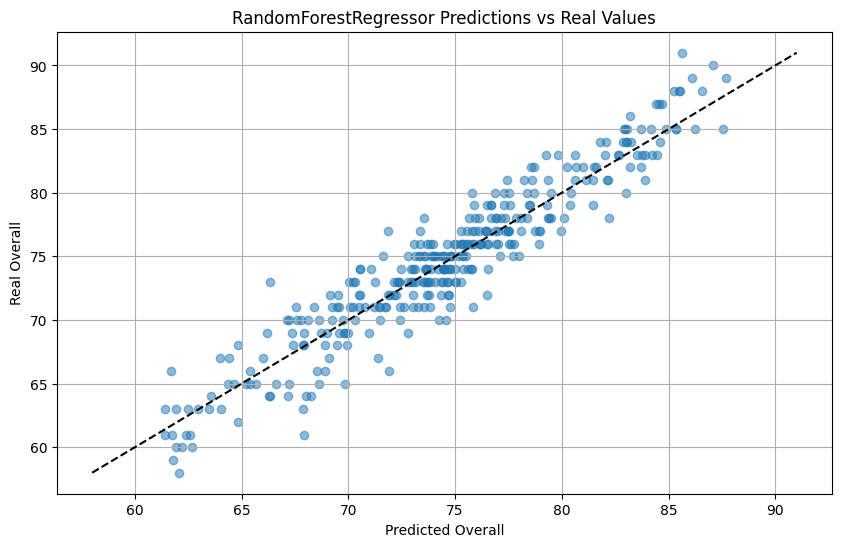

In [14]:
# Creating the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(results_df['Predicted Overall'], results_df['Real Overall'], alpha=0.5)

# Adding the x = y line
plt.plot([results_df['Real Overall'].min(), results_df['Real Overall'].max()], 
         [results_df['Real Overall'].min(), results_df['Real Overall'].max()], 
         color='black', linestyle='--')

plt.title('RandomForestRegressor Predictions vs Real Values')
plt.xlabel('Predicted Overall')
plt.ylabel('Real Overall')
plt.grid(True)
plt.show()

In [15]:
rf_model = RandomForestRegressor(n_estimators=200, min_samples_split=2 ,random_state=1)

rf_model.fit(X_train, y_train)


y_pred = rf_model.predict(X_test)

# Calculate R2 score
r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2}')

results_df = pd.DataFrame({
    'Predicted Overall': y_pred,
    'Real Overall': y_test
})

mae = mean_absolute_error(results_df['Real Overall'], results_df['Predicted Overall'])
print(f'Mean Absolute Error (MAE): {mae}')
y_pred_class = np.round(y_pred).astype(int)
y_test_class = np.round(y_test).astype(int)

# Calculate classification metrics
accuracy_train = accuracy_score(np.round(y_train).astype(int), np.round(rf_model.predict(X_train)).astype(int))
accuracy_test = accuracy_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class, average='macro')
macro_recall = recall_score(y_test_class, y_pred_class, average='macro', zero_division=0)
macro_precision = precision_score(y_test_class, y_pred_class, average='macro', zero_division=0)

# Print classification metrics
print(f'Training Accuracy: {accuracy_train}')
print(f'Test Accuracy: {accuracy_test}')
print(f'F1 Score: {f1}')
print(f'Macro Recall: {macro_recall}')
print(f'Macro Precision: {macro_precision}')

# Display the results DataFrame
results_df = results_df.sort_values(by='Real Overall', ascending=False).reset_index()
middle_rows = len(results_df) // 2  # Calculate the middle index
(results_df.iloc[middle_rows - 5: middle_rows + 5])

R2 Score: 0.8974890204526679
Mean Absolute Error (MAE): 1.5927878787878789
Training Accuracy: 0.5918057663125948
Test Accuracy: 0.22424242424242424
F1 Score: 0.15236857657996214
Macro Recall: 0.15226127582528967
Macro Precision: 0.16158551415904357


,name,Predicted Overall,Real Overall
160,Florian Kainz,73.005,75.0
161,Mama Baldé,74.085,75.0
162,Vedat Muriqi,74.970,75.0
163,Opa Nguette,73.485,75.0
164,Ibrahima Traoré,71.545,75.0
165,Eldor Shomurodov,76.980,75.0
166,Maxwel Cornet,77.350,75.0
167,Romain Hamouma,74.895,75.0
168,Admir Mehmedi,75.520,74.0
169,Christian Benteke,74.385,74.0


In [20]:
X_test.to_csv('X_test')
y_test.to_csv('y_test')

In [21]:
asss =pd.read_csv('y_test', index_col = 'name')
asss['overall']

name
Félix Correia                66.0
Paulo Dybala                 86.0
Pierre-Emerick Aubameyang    85.0
Kaio Jorge                   71.0
Ángel Correa                 82.0
                             ... 
Dwight Gayle                 72.0
Yannick Carrasco             85.0
Nemanja Radonjić             74.0
Charles                      71.0
Chadrac Akolo                72.0
Name: overall, Length: 330, dtype: float64

In [22]:
y_test

name
Félix Correia                66.0
Paulo Dybala                 86.0
Pierre-Emerick Aubameyang    85.0
Kaio Jorge                   71.0
Ángel Correa                 82.0
                             ... 
Dwight Gayle                 72.0
Yannick Carrasco             85.0
Nemanja Radonjić             74.0
Charles                      71.0
Chadrac Akolo                72.0
Name: overall, Length: 330, dtype: float64

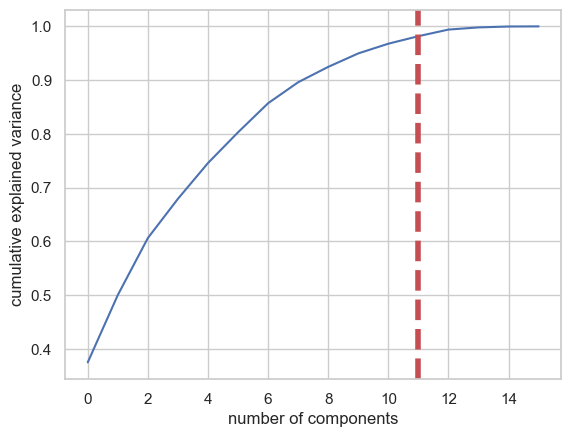

In [23]:
pca_test = PCA(n_components=16)
pca_test.fit(X_train_scaled)
sns.set(style='whitegrid')
plt.plot(np.cumsum(pca_test.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.axvline(linewidth=4, color='r', linestyle = '--', x=11, ymin=0, ymax=1)
plt.savefig('pca_variance.png', dpi=300)


evr = pca_test.explained_variance_ratio_
cvr = np.cumsum(pca_test.explained_variance_ratio_)
pca_df = pd.DataFrame()
pca_df['Cumulative Variance Ratio'] = cvr
pca_df['Explained Variance Ratio'] = evr


In [24]:
pca = PCA(n_components=11)
pca.fit(X_train_scaled)
X_train_scaled_pca = pca.transform(X_train_scaled)
X_test_scaled_pca = pca.transform(X_test_scaled)

In [25]:
rfc = RandomForestRegressor(n_estimators=150, min_samples_split=2, min_samples_leaf=1, random_state=45)
rfc.fit(X_train_scaled_pca, y_train)

y_pred = rfc.predict(X_test_scaled_pca)

# Calculate R2 score
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)


print(f'R2 Score: {r2}')
print(f'Mean Absolute Score: {mae}')

# wont use PCA loss info

R2 Score: 0.8467864741233991
Mean Absolute Score: 1.9070505050505049


In [26]:
rf_model = RandomForestRegressor(random_state=42)

# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create the GridSearchCV object
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

# Perform grid search on the training data
grid_search.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='r2')

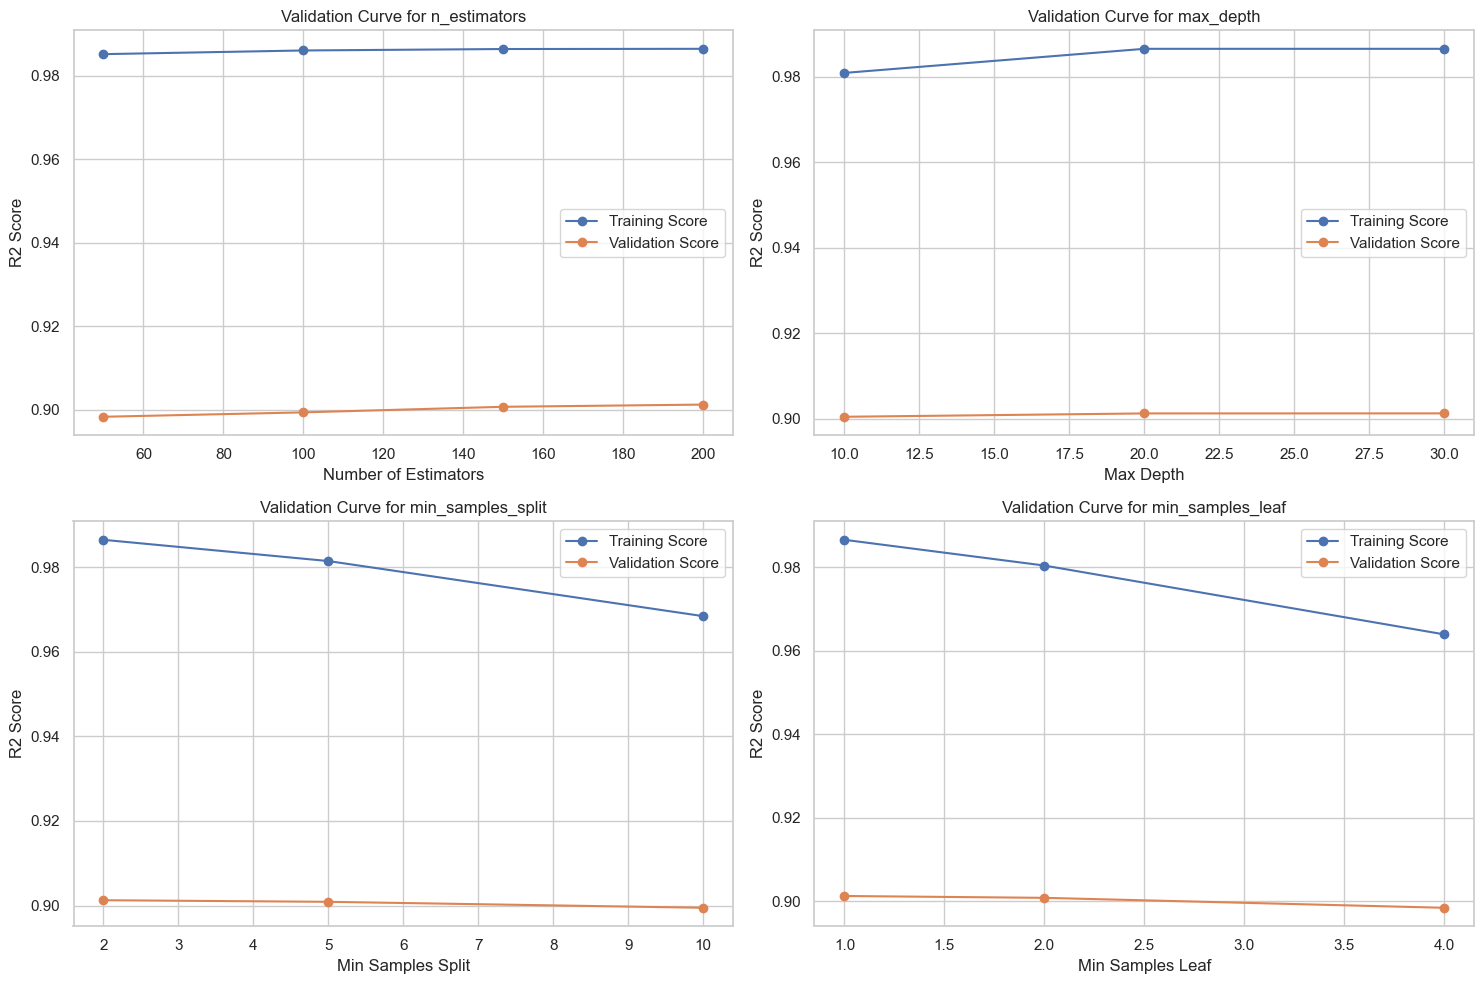

In [27]:
# Plot the validation curve for 'n_estimators'
param_range_estimators = np.arange(50, 201, 50)
train_scores_estimators, test_scores_estimators = validation_curve(
    RandomForestRegressor(random_state=42, max_depth=grid_search.best_params_['max_depth'],
                          min_samples_split=grid_search.best_params_['min_samples_split'],
                          min_samples_leaf=grid_search.best_params_['min_samples_leaf']),
    X_train_scaled, y_train, param_name='n_estimators', param_range=param_range_estimators, cv=5, scoring='r2', n_jobs=-1
)

# Plot the validation curve for 'max_depth'
param_range_depth = [None, 10, 20, 30]
train_scores_depth, test_scores_depth = validation_curve(
    RandomForestRegressor(random_state=42, n_estimators=grid_search.best_params_['n_estimators'],
                          min_samples_split=grid_search.best_params_['min_samples_split'],
                          min_samples_leaf=grid_search.best_params_['min_samples_leaf']),
    X_train_scaled, y_train, param_name='max_depth', param_range=param_range_depth, cv=5, scoring='r2', n_jobs=-1
)

# Plot the validation curve for 'min_samples_split'
param_range_split = [2, 5, 10]
train_scores_split, test_scores_split = validation_curve(
    RandomForestRegressor(random_state=42, n_estimators=grid_search.best_params_['n_estimators'],
                          max_depth=grid_search.best_params_['max_depth'],
                          min_samples_leaf=grid_search.best_params_['min_samples_leaf']),
    X_train_scaled, y_train, param_name='min_samples_split', param_range=param_range_split, cv=5, scoring='r2', n_jobs=-1
)

# Plot the validation curve for 'min_samples_leaf'
param_range_leaf = [1, 2, 4]
train_scores_leaf, test_scores_leaf = validation_curve(
    RandomForestRegressor(random_state=42, n_estimators=grid_search.best_params_['n_estimators'],
                          max_depth=grid_search.best_params_['max_depth'],
                          min_samples_split=grid_search.best_params_['min_samples_split']),
    X_train_scaled, y_train, param_name='min_samples_leaf', param_range=param_range_leaf, cv=5, scoring='r2', n_jobs=-1
)

# Plot the validation curves
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(param_range_estimators, np.mean(train_scores_estimators, axis=1), label='Training Score', marker='o')
plt.plot(param_range_estimators, np.mean(test_scores_estimators, axis=1), label='Validation Score', marker='o')
plt.title('Validation Curve for n_estimators')
plt.xlabel('Number of Estimators')
plt.ylabel('R2 Score')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(param_range_depth, np.mean(train_scores_depth, axis=1), label='Training Score', marker='o')
plt.plot(param_range_depth, np.mean(test_scores_depth, axis=1), label='Validation Score', marker='o')
plt.title('Validation Curve for max_depth')
plt.xlabel('Max Depth')
plt.ylabel('R2 Score')
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(param_range_split, np.mean(train_scores_split, axis=1), label='Training Score', marker='o')
plt.plot(param_range_split, np.mean(test_scores_split, axis=1), label='Validation Score', marker='o')
plt.title('Validation Curve for min_samples_split')
plt.xlabel('Min Samples Split')
plt.ylabel('R2 Score')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(param_range_leaf, np.mean(train_scores_leaf, axis=1), label='Training Score', marker='o')
plt.plot(param_range_leaf, np.mean(test_scores_leaf, axis=1), label='Validation Score', marker='o')
plt.title('Validation Curve for min_samples_leaf')
plt.xlabel('Min Samples Leaf')
plt.ylabel('R2 Score')
plt.legend()

plt.tight_layout()
plt.show()

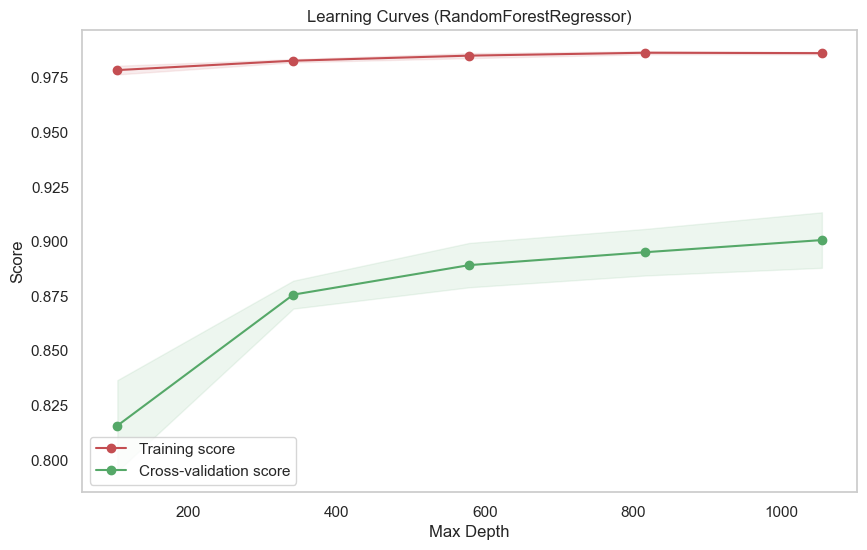

In [28]:
from sklearn.model_selection import learning_curve
def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(0.1, 1.0, 5)):
    """
    Generate a simple plot of the test and training learning curve.
    """
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 6))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel("Max Depth")
    axes.set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes,
        return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plot learning curve
    axes.grid()
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std,
                      train_scores_mean + train_scores_std, alpha=0.1,
                      color="r")
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std,
                      test_scores_mean + test_scores_std, alpha=0.1,
                      color="g")
    axes.plot(train_sizes, train_scores_mean, 'o-', color="r",
              label="Training score")
    axes.plot(train_sizes, test_scores_mean, 'o-', color="g",
              label="Cross-validation score")
    axes.legend(loc="best")

    return plt

# Plot the learning curve
cv = 5  # Cross-validation splitting strategy
title = "Learning Curves (RandomForestRegressor)"
model = RandomForestRegressor(n_estimators=120, random_state=1)
plot_learning_curve(model, title, X_train, y_train, cv=cv, n_jobs=-1)
plt.show()

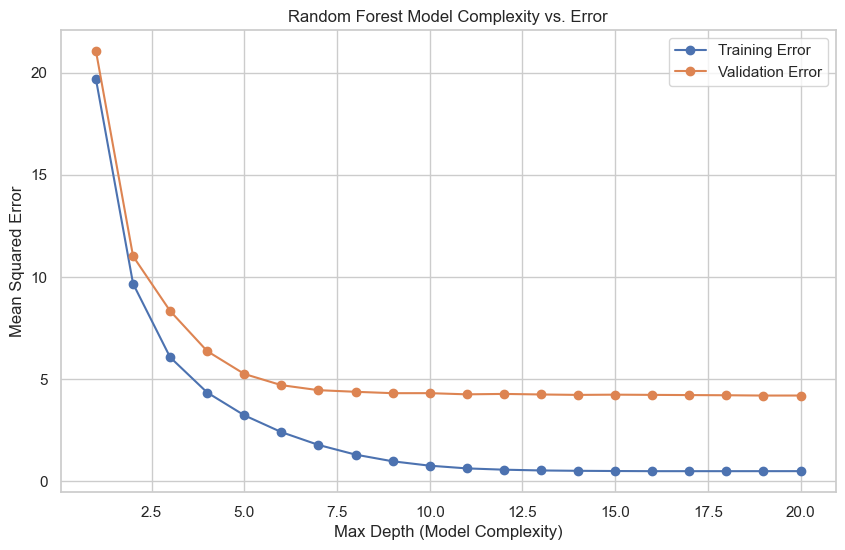

In [29]:
# Vary the max_depth hyperparameter to see its effect on error
max_depth_values = range(1, 21)
train_errors = []
val_errors = []

for max_depth in max_depth_values:
    # Initialize and train the Random Forest Regressor model with varying max_depth
    rf_model = RandomForestRegressor(max_depth=max_depth, random_state=42)
    rf_model.fit(X_train_scaled, y_train)

    # Make predictions on the training set
    y_train_pred = rf_model.predict(X_train_scaled)
    train_error = mean_squared_error(y_train, y_train_pred)
    train_errors.append(train_error)

    # Make predictions on the validation set
    y_val_pred = rf_model.predict(X_test_scaled)
    val_error = mean_squared_error(y_test, y_val_pred)
    val_errors.append(val_error)

# Plot the errors against the model complexity
plt.figure(figsize=(10, 6))
plt.plot(max_depth_values, train_errors, label='Training Error', marker='o')
plt.plot(max_depth_values, val_errors, label='Validation Error', marker='o')
plt.xlabel('Max Depth (Model Complexity)')
plt.ylabel('Mean Squared Error')
plt.title('Random Forest Model Complexity vs. Error')
plt.legend()
plt.show()

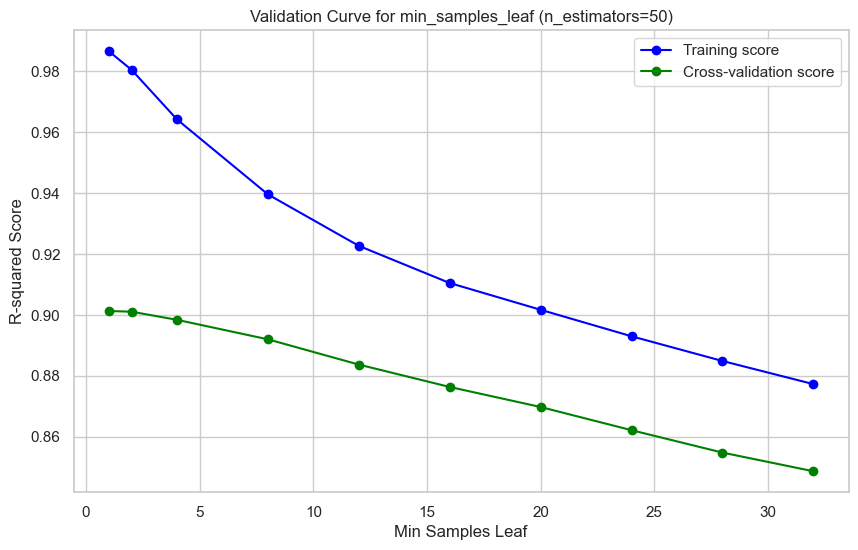

In [30]:
# Define hyperparameters to tune
param_grid = {
    'min_samples_leaf': [1, 2, 4, 8, 12, 16, 20, 24, 28, 32]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=5, return_train_score=True, scoring='r2')

# Your data (X_train, y_train) and fitting the model go here

# Fit the model on the training data
grid_search.fit(X_train, y_train)

# Extract results from the GridSearchCV
results_pv = grid_search.cv_results_

# Get the hyperparameter values and scores
param_values = param_grid['min_samples_leaf']
train_scores_mean = results_pv['mean_train_score']
test_scores_mean = results_pv['mean_test_score']

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(param_values, train_scores_mean, label='Training score', color='blue', marker='o')
plt.plot(param_values, test_scores_mean, label='Cross-validation score', color='green', marker='o')
plt.title('Validation Curve for min_samples_leaf (n_estimators=50)')
plt.xlabel('Min Samples Leaf')
plt.ylabel('R-squared Score')  # Using R-squared as the metric
plt.legend(loc='best')
plt.grid(True)
plt.show()


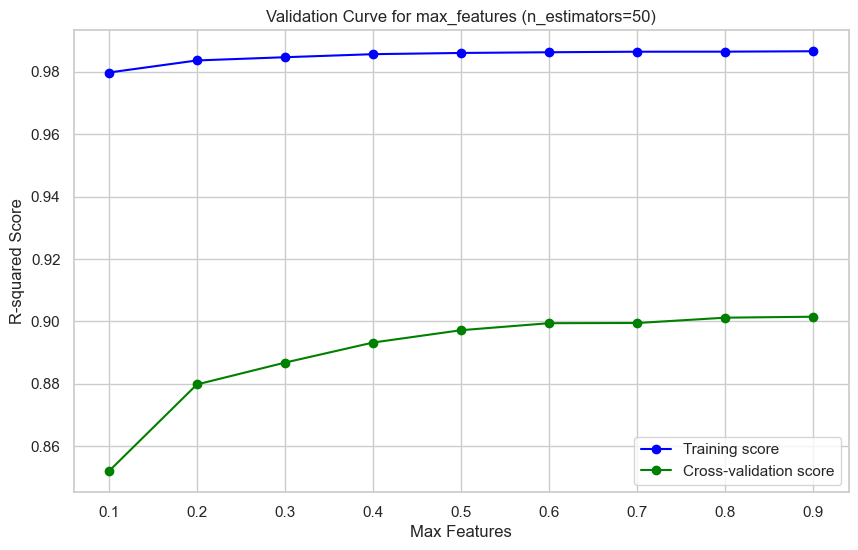

In [31]:
# Define hyperparameters to tune
param_grid = {
    'max_features': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, None]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=5, return_train_score=True, scoring='r2')

# Your data (X_train, y_train) and fitting the model go here

# Fit the model on the training data
grid_search.fit(X_train, y_train)

# Extract results from the GridSearchCV
results_pv = grid_search.cv_results_

# Get the hyperparameter values and scores
param_values = param_grid['max_features']
train_scores_mean = results_pv['mean_train_score']
test_scores_mean = results_pv['mean_test_score']

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(param_values, train_scores_mean, label='Training score', color='blue', marker='o')
plt.plot(param_values, test_scores_mean, label='Cross-validation score', color='green', marker='o')
plt.title('Validation Curve for max_features (n_estimators=50)')
plt.xlabel('Max Features')
plt.ylabel('R-squared Score')  # Using R-squared as the metric
plt.legend(loc='best')
plt.grid(True)
plt.show()


In [21]:
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Initialize the XGBoost Regressor model
model = XGBRegressor(objective ='reg:squarederror', random_state=42)
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Fit the model on the training data
model.fit(X_train_scaled, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test_scaled)

# Calculate mean squared error and R-squared
mse = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Create a dataframe with actual and predicted ranks along with player names
results_df = pd.DataFrame({
   # 'Player': X_test.index,  # Assuming the player names are the index in X_test
    'Real Overall': y_test,
    'Predicted Overall': y_pred
})

# Print the names, actual ranks, predicted ranks, errors, and score
print(results_df[['Real Overall', 'Predicted Overall']])
print(f'Mean Absolute Error: {mse}')
print(f'R-squared: {r2}')
#
y_pred_class = np.round(y_pred).astype(int)
y_test_class = np.round(y_test).astype(int)

# Calculate classification metrics
accuracy_train = accuracy_score(np.round(y_train).astype(int), np.round(model.predict(X_train_scaled)).astype(int))
accuracy_test = accuracy_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class, average='macro')
macro_recall = recall_score(y_test_class, y_pred_class, average='macro', zero_division=0)
macro_precision = precision_score(y_test_class, y_pred_class, average='macro', zero_division=0)

# Print classification metrics
print(f'Training Accuracy: {accuracy_train}')
print(f'Test Accuracy: {accuracy_test}')
print(f'F1 Score: {f1}')
print(f'Macro Recall: {macro_recall}')
print(f'Macro Precision: {macro_precision}')
#

                           Real Overall  Predicted Overall
name                                                      
Félix Correia                      66.0          65.423340
Paulo Dybala                       86.0          83.133110
Pierre-Emerick Aubameyang          85.0          82.436172
Kaio Jorge                         71.0          69.513557
Ángel Correa                       82.0          81.473045
...                                 ...                ...
Rubén Vargas                       75.0          75.455193
Sambou Soumano                     67.0          64.923119
Andy Carroll                       74.0          70.190926
Fábio Silva                        70.0          73.834946
Timothé Nkada                      59.0          62.601738

[824 rows x 2 columns]
Mean Absolute Error: 1.6074057736443084
R-squared: 0.8838538001066006
Training Accuracy: 1.0
Test Accuracy: 0.20024271844660194
F1 Score: 0.1825465467899717
Macro Recall: 0.18487181928949487
Macro Precision: 0

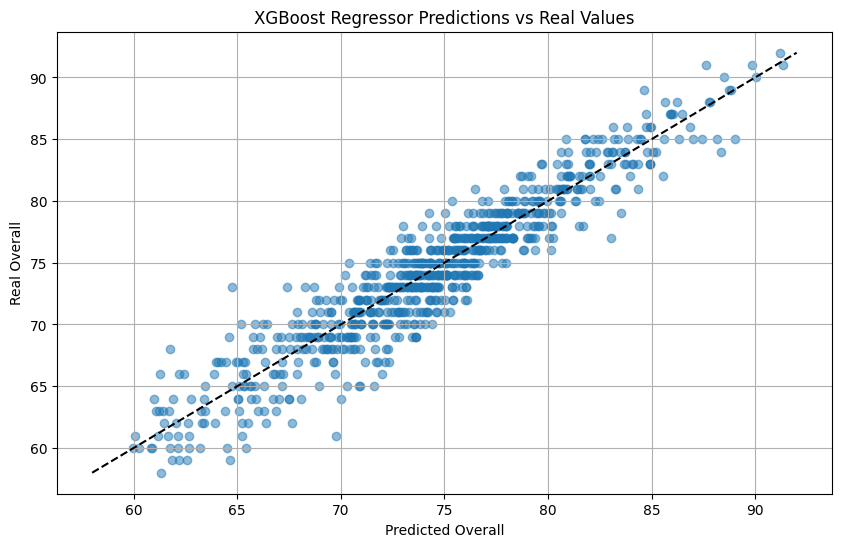

In [23]:
# Creating the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(results_df['Predicted Overall'], results_df['Real Overall'], alpha=0.5)

# Adding the x = y line
plt.plot([results_df['Real Overall'].min(), results_df['Real Overall'].max()], 
         [results_df['Real Overall'].min(), results_df['Real Overall'].max()], 
         color='black', linestyle='--')

plt.title('XGBoost Regressor Predictions vs Real Values')
plt.xlabel('Predicted Overall')
plt.ylabel('Real Overall')
plt.grid(True)
plt.show()

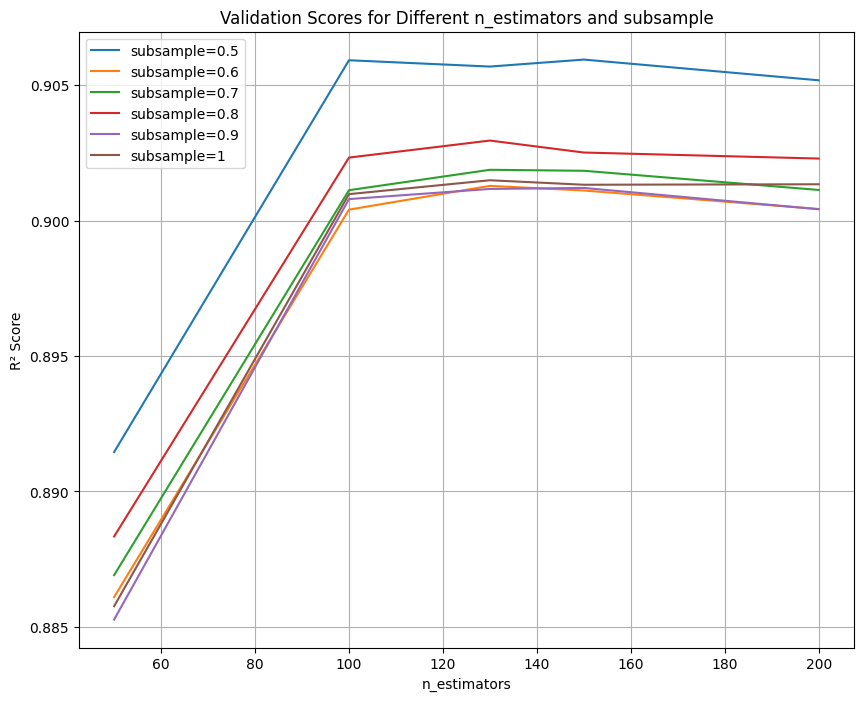

In [25]:
import matplotlib.pyplot as plt

# Adjusted parameter grid (excluding 1 for min_samples_split)
param_grid = {
    'n_estimators': [50, 100, 130, 150, 200],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1]
}

# Prepare the plot
plt.figure(figsize=(10, 8))
plt.title("Validation Scores for Different n_estimators and subsample")
plt.xlabel("n_estimators")
plt.ylabel("R² Score")
plt.grid(True)

# Plotting a line for each min_samples_split value
for subsample in param_grid['subsample']:
    scores = []
    for n_estimators in param_grid['n_estimators']:
        model = XGBRegressor(objective ='reg:squarederror',
                             random_state=1,
                            eta=0.06,
                            max_depth=4)        
        model.set_params(subsample=subsample, n_estimators=n_estimators)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        r2 = r2_score(y_test, y_pred)
        scores.append(r2)
    plt.plot(param_grid['n_estimators'], scores, label=f'subsample={subsample}')

# Add legend
plt.legend()
plt.show()

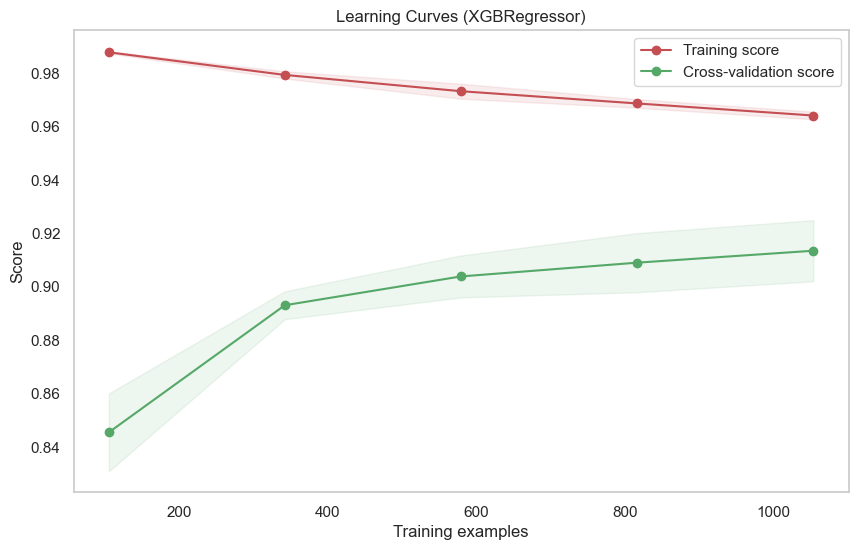

In [42]:
from sklearn.model_selection import learning_curve
import numpy as np

# Learning curve function
def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(0.1, 1.0, 5)):
    """
    Generate a simple plot of the test and training learning curve.
    """
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 6))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel("Training examples")
    axes.set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes,
        return_times=True)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plot learning curve
    axes.grid()
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std,
                      train_scores_mean + train_scores_std, alpha=0.1,
                      color="r")
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std,
                      test_scores_mean + test_scores_std, alpha=0.1,
                      color="g")
    axes.plot(train_sizes, train_scores_mean, 'o-', color="r",
              label="Training score")
    axes.plot(train_sizes, test_scores_mean, 'o-', color="g",
              label="Cross-validation score")
    axes.legend(loc="best")

    return plt

# Plot the learning curve
cv = 5  # Cross-validation splitting strategy
title = "Learning Curves (XGBRegressor)"
model = XGBRegressor(objective ='reg:squarederror',
                     random_state=1,
                     eta=0.06,
                     max_depth = 4,
                     subsample = 0.7,
                    n_estimators=130,
                    gamma = 1,
                     reg_alpha = 0,
                    min_child_weight=6)
#model = RandomForestRegressor(n_estimators=120, random_state=1)
plot_learning_curve(model, title, X_train_scaled, y_train, cv=cv, n_jobs=-1)
plt.show()

Best parameters found:  {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
SVM R2 Score: 0.8437165460128684
Mean Absolute Error (MAE): 1.494077984629057
Training Accuracy: 0.898958971218616
Test Accuracy: 0.8679706601466992
Macro Recall: 0.8668350168350168
Macro Precision: 0.8674182203593968
F1 Score: 0.8671055165110233
                   Predicted Overall  Real Overall  Difference
name                                                          
Marlon                     74.129635          72.0    2.129635
Omar Alderete              73.287084          74.0   -0.712916
Romain Thomas              76.130667          76.0    0.130667
Issa Diop                  76.477844          77.0   -0.522156
Giuseppe Pezzella          69.571492          72.0   -2.428508


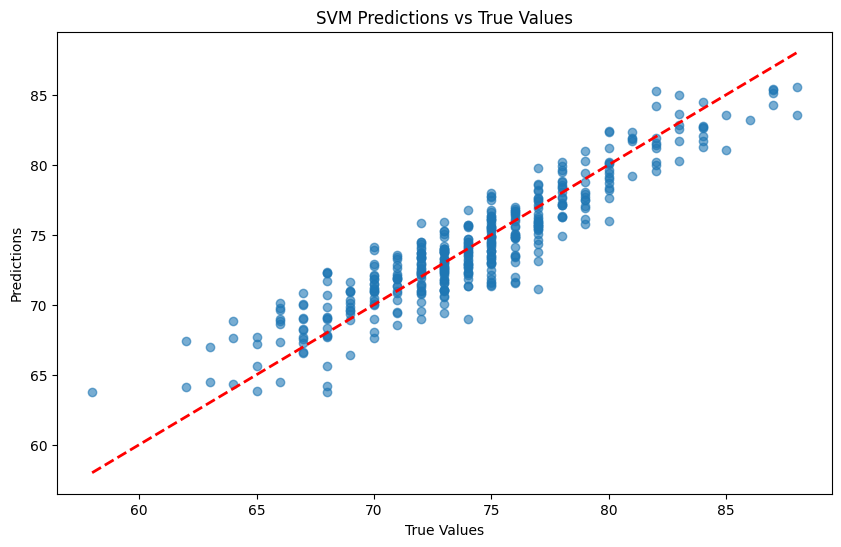

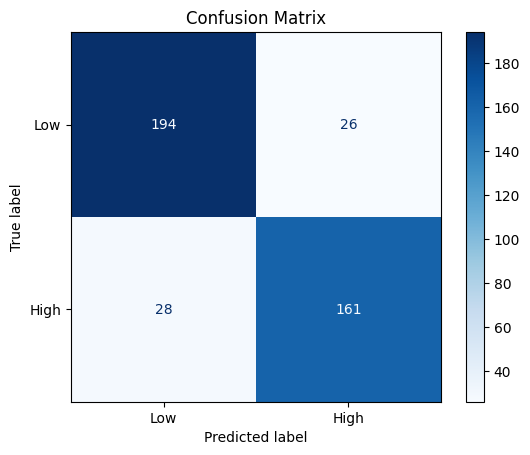

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('fifa.csv', index_col = 'name')

#forwards=data[data['position']=='Attack']
#forwards=forwards.drop(['position','data_year', 'position'], axis=1)

Defenders=data[data['position']=='Defender']
Defenders=Defenders.drop(['position','data_year', 'position'], axis=1)

features = Defenders.drop('overall', axis=1)
target = Defenders['overall']
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
    
# Initialize and train SVM Regressor with GridSearchCV for hyperparameter tuning
param_grid = {
    'C': [0.1, 1, 10, 100],
    #'C': [0.5, 5, 50, 500],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear', 'poly']
    }
grid_search = GridSearchCV(SVR(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)
    
# Best parameters from GridSearchCV
print("Best parameters found: ", grid_search.best_params_)
# Train the final SVM model with the best parameters
best_svm = grid_search.best_estimator_
best_svm.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_svm = best_svm.predict(X_test_scaled)
#print("SVM RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_svm)))
print("SVM R2 Score:", r2_score(y_test, y_pred_svm))

#new metrics
y_train_pred = best_svm.predict(X_train_scaled)
y_test_pred = best_svm.predict(X_test_scaled)

# Discretize the target for classification-like metrics
threshold = np.median(target)
y_train_class = (y_train > threshold).astype(int)
y_test_class = (y_test > threshold).astype(int)
y_train_pred_class = (y_train_pred > threshold).astype(int)
y_test_pred_class = (y_test_pred > threshold).astype(int)

# Compute classification-like metrics
train_accuracy = np.mean(y_train_class == y_train_pred_class)
test_accuracy = np.mean(y_test_class == y_test_pred_class)
macro_recall = recall_score(y_test_class, y_test_pred_class, average='macro')
macro_precision = precision_score(y_test_class, y_test_pred_class, average='macro')
f1 = f1_score(y_test_class, y_test_pred_class, average='macro')
#Dataframe
svm_results = pd.DataFrame({
    #'Name': player_test,
    'Predicted Overall': y_test_pred,
    'Real Overall': y_test,
    'Difference': (y_test_pred - y_test)
})
mae = mean_absolute_error(svm_results['Real Overall'], svm_results['Predicted Overall'])
print(f'Mean Absolute Error (MAE): {mae}')
print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Macro Recall:", macro_recall)
print("Macro Precision:", macro_precision)
print("F1 Score:", f1)

#ends
print(svm_results.head())
# Visualization
# Plot true vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_svm, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('SVM Predictions vs True Values')
plt.show()

#ends
# Compute the confusion matrix
cm = confusion_matrix(y_test_class, y_test_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

Epoch 1/100
32/32 [==============================] - 14s 117ms/step - loss: 5210.9126 - val_loss: 4613.4585
Epoch 2/100
32/32 [==============================] - 1s 17ms/step - loss: 3013.2478 - val_loss: 1106.8073
Epoch 3/100
32/32 [==============================] - 0s 14ms/step - loss: 607.7982 - val_loss: 352.3510
Epoch 4/100
32/32 [==============================] - 0s 5ms/step - loss: 329.1945 - val_loss: 281.4062
Epoch 5/100
32/32 [==============================] - 0s 5ms/step - loss: 268.5744 - val_loss: 243.0637
Epoch 6/100
32/32 [==============================] - 0s 5ms/step - loss: 232.2489 - val_loss: 216.4757
Epoch 7/100
32/32 [==============================] - 0s 4ms/step - loss: 205.6866 - val_loss: 198.6393
Epoch 8/100
32/32 [==============================] - 0s 6ms/step - loss: 185.4279 - val_loss: 181.8344
Epoch 9/100
32/32 [==============================] - 0s 4ms/step - loss: 166.1230 - val_loss: 167.8947
Epoch 10/100
32/32 [==============================] - 0s 4ms/ste

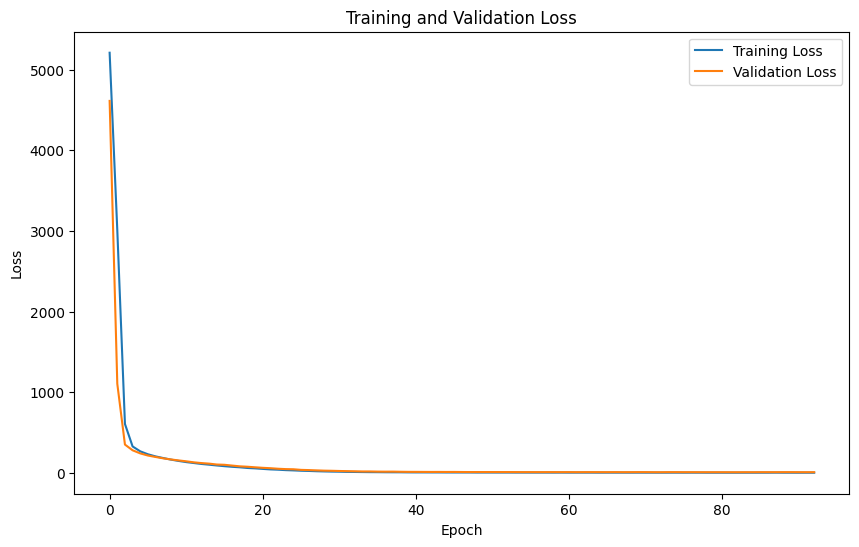

32/32 [==============================] - 0s 1ms/step
Training Accuracy: 0.23702252693437806
Test Accuracy: 0.1860920666013712
Macro Recall: 0.12035897748677549
Macro Precision: 0.12983017762432703
F1 Score: 0.12226426802623908
32/32 [==============================] - 0s 1ms/step
Neural Network MAE: 1.870302067680994
Neural Network R2 Score: 0.6087307362136082
                   Predicted Overall  Real Overall
name                                              
Marlon                     75.312134          72.0
Omar Alderete              72.495255          74.0
Romain Thomas              75.447815          76.0
Issa Diop                  75.093971          77.0
Giuseppe Pezzella          69.869980          72.0


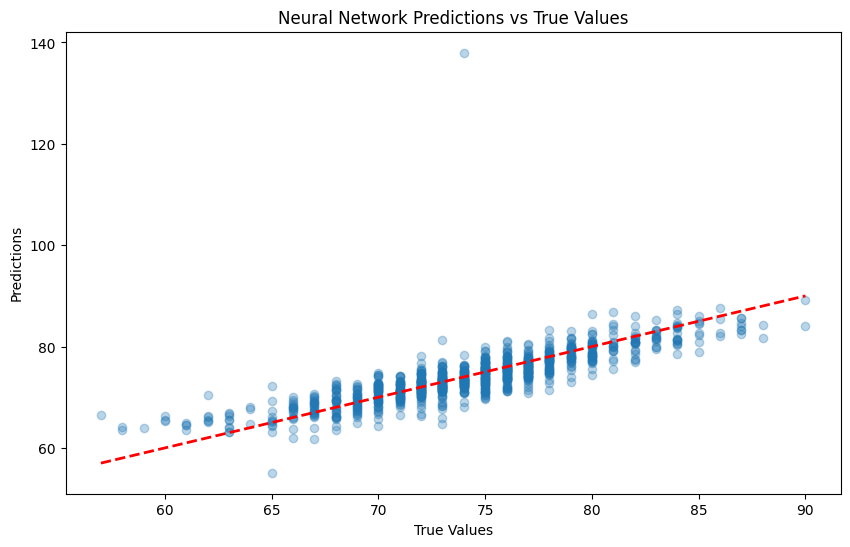

In [30]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix , ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# Load your dataset
# Make sure to adjust the path and dataset name
data = pd.read_csv('fifa.csv', index_col = 'name')

Defenders = data[data['position'] == 'Defender']
Defenders = Defenders.drop(['position', 'data_year'], axis=1)

# Separate features and target variable
features = Defenders.drop('overall', axis=1)
target = Defenders['overall']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.5, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the neural network model
model = Sequential()
model.add(Dense(128, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test), epochs=100, batch_size=32, callbacks=[early_stopping])

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Predict on training and test sets
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Evaluate performance
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
# Convert predictions and actual values to integer classes for classification metrics
# For simplicity, we'll round the predictions and actual values to the nearest integer
y_train_pred_class = np.round(y_train_pred).astype(int).flatten()
y_test_pred_class = np.round(y_test_pred).astype(int).flatten()
y_train_class = np.round(y_train).astype(int)
y_test_class = np.round(y_test).astype(int)

# Compute metrics
train_accuracy = accuracy_score(y_train_class, y_train_pred_class)
test_accuracy = accuracy_score(y_test_class, y_test_pred_class)
macro_recall = recall_score(y_test_class, y_test_pred_class, average='macro', zero_division=0)
macro_precision = precision_score(y_test_class, y_test_pred_class, average='macro', zero_division=0)
f1 = f1_score(y_test_class, y_test_pred_class, average='macro', zero_division=0)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Macro Recall:", macro_recall)
print("Macro Precision:", macro_precision)
print("F1 Score:", f1)
y_pred_nn = model.predict(X_test_scaled)
print("Neural Network MAE:", mean_absolute_error(y_test, y_pred_nn))
print("Neural Network R2 Score:", r2_score(y_test, y_pred_nn))

# Create a DataFrame for the output
output = pd.DataFrame({
    'Predicted Overall': y_test_pred.flatten(),
    'Real Overall': y_test
})
#mae = mean_absolute_error(output['Real Overall'], output['Predicted Overall'])
#print(f'Mean Absolute Error (MAE): {mae}')
# Display the output DataFrame
print(output.head())


# Visualization
# Plot true vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Neural Network Predictions vs True Values')
plt.show()
